## Task 2: Hate Speech Detection

### 1.	Data Exploration and Pre-processing

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
# Load the hate speech dataset
df = pd.read_csv("labeled_data.csv")

# Display the first five records
df.head(8)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
5,5,3,1,2,0,1,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just..."
6,6,3,0,3,0,1,"!!!!!!""@__BrighterDays: I can not just sit up ..."
7,7,3,0,3,0,1,!!!!&#8220;@selfiequeenbri: cause I'm tired of...


### 1.2 Dataset Overview and Structure

In [15]:
# Display dataset dimensions
print("Dataset Shape:", df.shape)

# Display column names and data types
df.info()



Dataset Shape: (24783, 7)
<class 'pandas.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          24783 non-null  int64
 1   count               24783 non-null  int64
 2   hate_speech         24783 non-null  int64
 3   offensive_language  24783 non-null  int64
 4   neither             24783 non-null  int64
 5   class               24783 non-null  int64
 6   tweet               24783 non-null  str  
dtypes: int64(6), str(1)
memory usage: 1.3 MB


In [19]:
# Display summary statistics for numerical columns
df.describe()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class
count,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000,24783.000000
mean,12681.192027,3.243473,0.280515,2.413711,0.549247,1.110277
std,7299.553863,0.883060,0.631851,1.399459,1.113299,0.462089
min,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
25%,6372.500000,3.000000,0.000000,2.000000,0.000000,1.000000
50%,12703.000000,3.000000,0.000000,3.000000,0.000000,1.000000
75%,18995.500000,3.000000,0.000000,3.000000,0.000000,1.000000
max,25296.000000,9.000000,7.000000,9.000000,9.000000,2.000000


### 1.3 Check for Missing Values

In [5]:
# Check for missing values in each column
df.isnull().sum()


Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

### 1.4 Target Variable Analysis (Class Distribution)

In [20]:
# Display class distribution
df['class'].value_counts()


class
1    19190
2     4163
0     1430
Name: count, dtype: int64

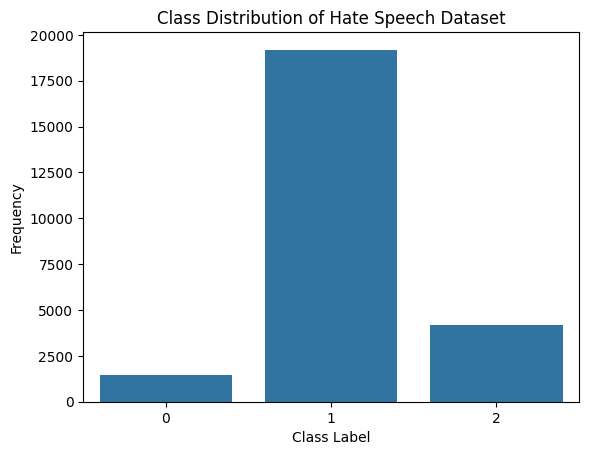

In [7]:
# Visualise class imbalance
plt.figure()
sns.countplot(x='class', data=df)
plt.title("Class Distribution of Hate Speech Dataset")
plt.xlabel("Class Label")
plt.ylabel("Frequency")
plt.show()


### 1.5 Text Data Inspection

In [22]:
# Inspect sample tweets
df['tweet'].sample(5, random_state=42)


2281           934 8616\ni got a missed call from yo bitch
15914    RT @KINGTUNCHI_: Fucking with a bad bitch you ...
18943    RT @eanahS__: @1inkkofrosess lol my credit ain...
16407    RT @Maxin_Betha Wipe the cum out of them faggo...
13326    Niggas cheat on they bitch and don't expect no...
Name: tweet, dtype: str

### 1.6 Basic Text Cleaning (Pre-processing)

In [29]:
import re

def clean_text(text):
    text = text.lower()                              # Convert to lowercase
    text = re.sub(r"http\S+", "", text)               # Remove URLs
    text = re.sub(r"@\w+", "", text)                  # Remove mentions
    text = re.sub(r"#", "", text)                     # Remove hashtag symbols
    text = re.sub(r"[^a-z\s]", "", text)              # Remove punctuation & numbers
    text = text.strip()                               # Remove extra spaces
    return text

# Apply text cleaning
df['clean_tweet'] = df['tweet'].apply(clean_text)

# Display cleaned text examples
df[['tweet', 'clean_tweet']].head()


,tweet,clean_tweet
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldnt complain about cle...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats coldtyga dwn bad for cuffin dat h...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she sta...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true o...


In [30]:
# Verify dataset integrity after preprocessing
df.isnull().sum()


Unnamed: 0            0
count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
clean_tweet           0
dtype: int64

In [31]:
# Check available columns and a quick sample
print(df.columns.tolist())
print('clean_tweet' in df.columns)
df.head(5)

['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet', 'clean_tweet']
True


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,clean_tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldnt complain about cle...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats coldtyga dwn bad for cuffin dat h...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she sta...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true o...


In [32]:
# Display the first five records
df.head()


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet,clean_tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldnt complain about cle...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats coldtyga dwn bad for cuffin dat h...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she sta...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true o...


## 2. Feature Engineering Process

In [33]:
# Feature extraction for text data
from sklearn.feature_extraction.text import TfidfVectorizer

# Dimensionality reduction
from sklearn.decomposition import PCA

#Justification:

#TfidfVectorizer converts unstructured text into numerical form

# PCA reduces dimensionality while preserving variance


### 2.1 Feature Extraction Using TF-IDF

In [34]:
# Initialise TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2)
)

# Transform cleaned tweets into TF-IDF features
X_tfidf = tfidf.fit_transform(df['clean_tweet'])

# Target variable
y = df['class']

# Display feature matrix shape
print("TF-IDF Feature Matrix Shape:", X_tfidf.shape)


TF-IDF Feature Matrix Shape: (24783, 5000)


### 2.2 Justification of Feature Encoding Choice
Why TF-IDF instead of Bag-of-Words or Word Embeddings?

Bag-of-Words ignores term importance

Word embeddings require large corpora and complex tuning

TF-IDF offers:

Interpretability

Efficiency

Strong baseline performance for hate speech detection

### 2.3 Dimensionality Reduction Using PCA

In [35]:
# Convert sparse matrix to dense for PCA
X_dense = X_tfidf.toarray()

# Apply PCA to retain 95% variance
pca = PCA(n_components=0.95, random_state=42)

X_pca = pca.fit_transform(X_dense)

# Display reduced feature shape
print("PCA Reduced Feature Shape:", X_pca.shape)



PCA Reduced Feature Shape: (24783, 3652)


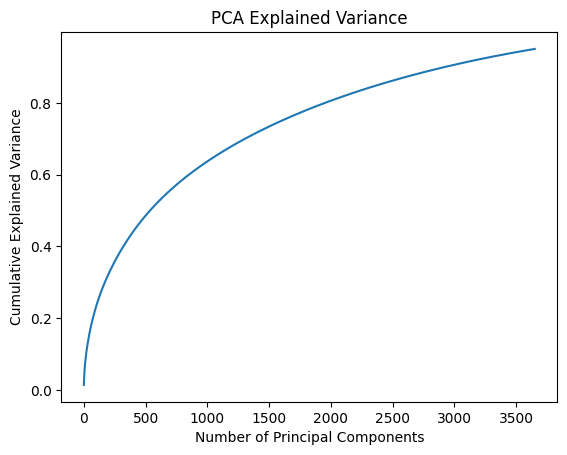

In [36]:
# Plot cumulative explained variance
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


## 3. Model Selection & Training

#### 3.1 Import Libraries for Model Training

In [37]:
# Data splitting
from sklearn.model_selection import train_test_split

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB


In [38]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (19826, 3652)
Testing set shape: (4957, 3652)


#### 3.2 Train Logistic Regression

In [39]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_reg.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

#### 3.3 Train Support Vector Machine (SVM)

In [40]:
svm_model = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### 3.4 Train Random Forest Classifier

In [41]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 3.5 Train Gradient Boosting Classifier

In [42]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_model.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

#### 3.6 Train Naïve Bayes Classifier

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
# X_tfidf is introduced because it does not accept negative values from the PCA output

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## 4. Hyperparameter Tuning

In [44]:
# Hyperparameter tuning and cross-validation
from sklearn.model_selection import GridSearchCV


#### 4.1 Hyperparameter Tuning – Logistic Regression

In [45]:
# Define hyperparameter grid for Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Base model
log_reg = LogisticRegression(max_iter=2000)

# Hyperparameter grid
log_reg_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

# Grid search
log_reg_grid = GridSearchCV(
    estimator=log_reg,
    param_grid=log_reg_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

# Fit
log_reg_grid.fit(X_train, y_train)

# Results
print("Best Logistic Regression Parameters:", log_reg_grid.best_params_)
print("Best Score:", log_reg_grid.best_score_)



c:\Users\Upwork\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Logistic Regression Parameters: {'C': 10, 'penalty': 'l2'}
Best Score: 0.8824619733284826


#### 4.2 Hyperparameter Tuning – Support Vector Machine (SVM)

In [46]:
# Define hyperparameter grid for SVM
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM Parameters:", svm_grid.best_params_)


Best SVM Parameters: {'C': 1, 'kernel': 'rbf'}


#### 4.3 Hyperparameter Tuning – Random Forest

In [47]:
# Define hyperparameter grid for Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)


Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


#### 4.4 Hyperparameter Tuning – Gradient Boosting

In [48]:
# Define hyperparameter grid for Gradient Boosting
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)


Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


#### 4.5 Hyperparameter Tuning – Naïve Bayes

In [49]:
# Define hyperparameter grid for Naïve Bayes
nb_params = {
    'alpha': [0.1, 0.5, 1.0]
}

nb_grid = GridSearchCV(
    estimator=nb_model,
    param_grid=nb_params,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1
)

nb_grid.fit(X_train, y_train)

print("Best Naïve Bayes Parameters:", nb_grid.best_params_)


Best Naïve Bayes Parameters: {'alpha': 0.1}


#### 4.6 Store Best Models for Evaluation

In [50]:
# Extract best estimators
best_models = {
    "Logistic Regression": log_reg_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "Naïve Bayes": nb_grid.best_estimator_
}

print("Best models selected for evaluation.")


Best models selected for evaluation.


## 5 Model Evaluation & Comparative Analysis

In [51]:
# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    log_loss,
    classification_report
)
def evaluate_model(model, X_test, y_test):
    """
    Evaluates a classification model using multiple performance metrics.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted'),
        "ROC-AUC": roc_auc_score(y_test, y_proba, multi_class='ovr'),
        "Log Loss": log_loss(y_test, y_proba),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }


#### 5.1 Evaluate All Tuned Models

In [52]:
evaluation_results = {}

for model_name, model in best_models.items():
    evaluation_results[model_name] = evaluate_model(model, X_test, y_test)

print("Model evaluation completed.")


Model evaluation completed.


#### 5.2 Display Quantitative Results for Each Model

In [53]:
for model_name, results in evaluation_results.items():
    print(f"\nEvaluation Results for {model_name}")
    print("-" * 45)
    print(f"Accuracy   : {results['Accuracy']:.4f}")
    print(f"Precision  : {results['Precision']:.4f}")
    print(f"Recall     : {results['Recall']:.4f}")
    print(f"F1-Score   : {results['F1-Score']:.4f}")
    print(f"ROC-AUC    : {results['ROC-AUC']:.4f}")
    print(f"Log Loss   : {results['Log Loss']:.4f}")



Evaluation Results for Logistic Regression
---------------------------------------------
Accuracy   : 0.8899
Precision  : 0.8776
Recall     : 0.8899
F1-Score   : 0.8817
ROC-AUC    : 0.9095
Log Loss   : 0.3167

Evaluation Results for SVM
---------------------------------------------
Accuracy   : 0.8886
Precision  : 0.8926
Recall     : 0.8886
F1-Score   : 0.8890
ROC-AUC    : 0.9274
Log Loss   : 0.2818

Evaluation Results for Random Forest
---------------------------------------------
Accuracy   : 0.9003
Precision  : 0.8960
Recall     : 0.9003
F1-Score   : 0.8962
ROC-AUC    : 0.9281
Log Loss   : 0.3104

Evaluation Results for Gradient Boosting
---------------------------------------------
Accuracy   : 0.8899
Precision  : 0.8769
Recall     : 0.8899
F1-Score   : 0.8789
ROC-AUC    : 0.9164
Log Loss   : 0.3013

Evaluation Results for Naïve Bayes
---------------------------------------------
Accuracy   : 0.8630
Precision  : 0.8456
Recall     : 0.8630
F1-Score   : 0.8404
ROC-AUC    : 0.8957
Lo

#### 5.3 Classification Reports (Class-Level Analysis)

In [54]:
for model_name, model in best_models.items():
    print(f"\nClassification Report – {model_name}")
    print(classification_report(y_test, model.predict(X_test)))



Classification Report – Logistic Regression
              precision    recall  f1-score   support

           0       0.46      0.25      0.32       286
           1       0.92      0.95      0.93      3838
           2       0.84      0.83      0.83       833

    accuracy                           0.89      4957
   macro avg       0.74      0.68      0.70      4957
weighted avg       0.88      0.89      0.88      4957


Classification Report – SVM
              precision    recall  f1-score   support

           0       0.44      0.41      0.43       286
           1       0.95      0.91      0.93      3838
           2       0.78      0.94      0.85       833

    accuracy                           0.89      4957
   macro avg       0.72      0.75      0.74      4957
weighted avg       0.89      0.89      0.89      4957


Classification Report – Random Forest
              precision    recall  f1-score   support

           0       0.51      0.34      0.40       286
           1    

#### 5.4 Confusion Matrix Analysis

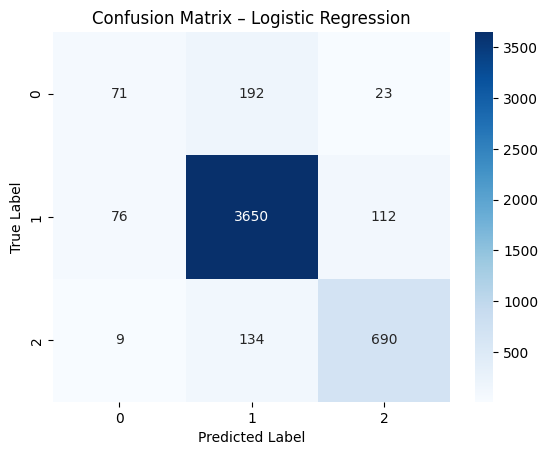

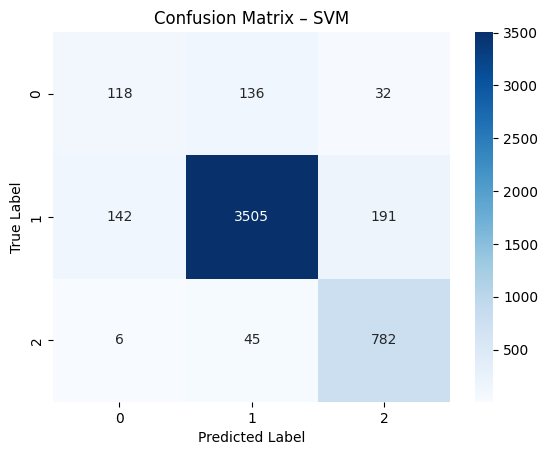

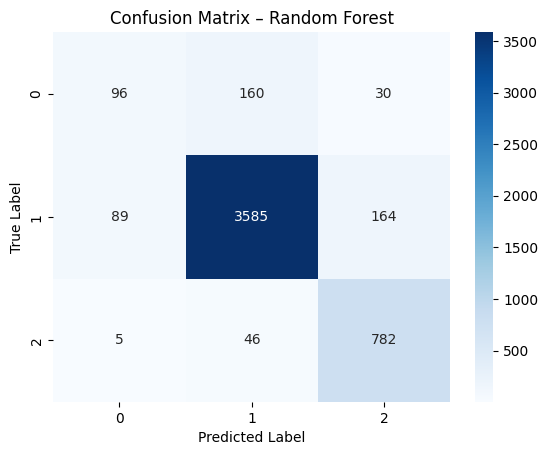

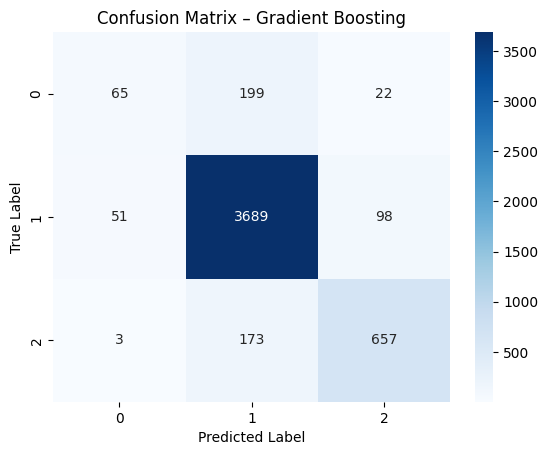

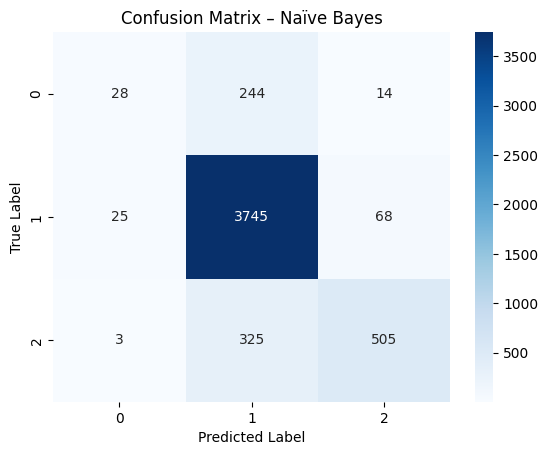

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, results in evaluation_results.items():
    plt.figure()
    sns.heatmap(
        results["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix – {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


#### 5.5 Comparative Performance Table

In [56]:
comparison_df = pd.DataFrame.from_dict(
    {
        model: {
            "Accuracy": results["Accuracy"],
            "Precision": results["Precision"],
            "Recall": results["Recall"],
            "F1-Score": results["F1-Score"],
            "ROC-AUC": results["ROC-AUC"],
            "Log Loss": results["Log Loss"]
        }
        for model, results in evaluation_results.items()
    },
    orient="index"
)

comparison_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Log Loss
Logistic Regression,0.889853,0.877582,0.889853,0.881733,0.909508,0.316719
SVM,0.888642,0.892591,0.888642,0.889026,0.927437,0.281762
Random Forest,0.900343,0.895981,0.900343,0.896234,0.928119,0.310371
Gradient Boosting,0.889853,0.876941,0.889853,0.878860,0.916429,0.301281
Naïve Bayes,0.863022,0.845555,0.863022,0.840356,0.895728,0.358032


#### 5.6 Best Model Selection

In [57]:
best_model_name = comparison_df["F1-Score"].idxmax()
best_model = best_models[best_model_name]

print("Best Performing Model:", best_model_name)


Best Performing Model: Random Forest


## 6 Model Deployment

#### 6.1 Create a Prediction Function

In [58]:
def predict_hate_speech(text, model, tfidf_vectorizer, pca_model):
    """
    Predicts the class of a given tweet using the deployed model.
    """
    # Clean input text
    text = clean_text(text)
    
    # Transform text using TF-IDF
    text_tfidf = tfidf_vectorizer.transform([text])
    
    # Apply PCA transformation
    text_pca = pca_model.transform(text_tfidf.toarray())
    
    # Generate prediction
    prediction = model.predict(text_pca)
    
    return prediction[0]


#### 6.2 Deploy the Best Model and Test Model on Unseen Data (Realistic Simulation)

In [59]:
def predict_hate_speech(text, model, tfidf_vectorizer):
    text = clean_text(text)
    text_tfidf = tfidf_vectorizer.transform([text])
    prediction = model.predict(text_tfidf)
    return prediction[0]

deployed_model = best_model

test_tweets = [
    "I hate these people, they should not exist",
    "What a beautiful day, feeling happy and blessed",
    "You are so stupid and worthless"
]

for tweet in test_tweets:
    result = predict_hate_speech(tweet, deployed_model, tfidf)
    print(f"Tweet: {tweet}")
    print(f"Predicted Class: {result}\n")

Tweet: I hate these people, they should not exist
Predicted Class: 2

Tweet: What a beautiful day, feeling happy and blessed
Predicted Class: 2

Tweet: You are so stupid and worthless
Predicted Class: 2

